In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hashlib
import matplotlib.ticker as ticker
def nd(arr):
    return np.asarray(arr).reshape(-1)

def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

def short_hash(s: str) -> str:
    """Generate a 7-character hash from a given string."""
    return hashlib.sha256(s.encode()).hexdigest()[:7]

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [75]:
# #522600 brown
# #307351 green
# #1C6087 blue
# #F75C03 orange
# #FFBA08 yellow


COLOR = {
    "source": "33658A",
    "target": "F6AE2D",
    "whitespace": "",
    "token": "",
    "taln": "",
    "difflib": "",
    "lcs": "",
    "naive": "",
}

In [76]:
from taln.taln_aln import (
    norm_text,
    tokenize,
    align_ng,
    align_lcs,
    align_difflib,
    reconstruct_target_by_idx,
    reconstruct_target_by_token,
)

In [77]:
cols = ["title", "question", "question_id", "is_impossible", "answer_type"]

In [78]:
# BOAT (pre-grouped) frames written by analysis/notebooks/make_ds.ipynb
tdf_t = pd.read_json("../../data/boat_train.tdf.json", orient="records")
tdf_d = pd.read_json("../../data/boat_dev.tdf.json", orient="records")
tdf = pd.concat([tdf_t, tdf_d])

wdf_t = pd.read_json("../../data/boat_train.wdf.json", orient="records")
wdf_d = pd.read_json("../../data/boat_dev.wdf.json", orient="records")
wdf = pd.concat([wdf_t, wdf_d])

# idx_start is stored as a JSON list; convert back to set to match downstream code
tdf["idx_start"] = tdf["idx_start"].apply(set)
wdf["idx_start"] = wdf["idx_start"].apply(set)

In [79]:
wdf.shape, tdf.shape, wdf.source.nunique(), tdf.source.nunique()

((35080, 3), (35080, 3), 14701, 14701)

In [80]:

# #522600 brown
# #307351 green
# #7EC9A2 light green
# #1C6087 blue
# #FE640B orange
# #FEA571 light orange
# #FFBA08 yellow

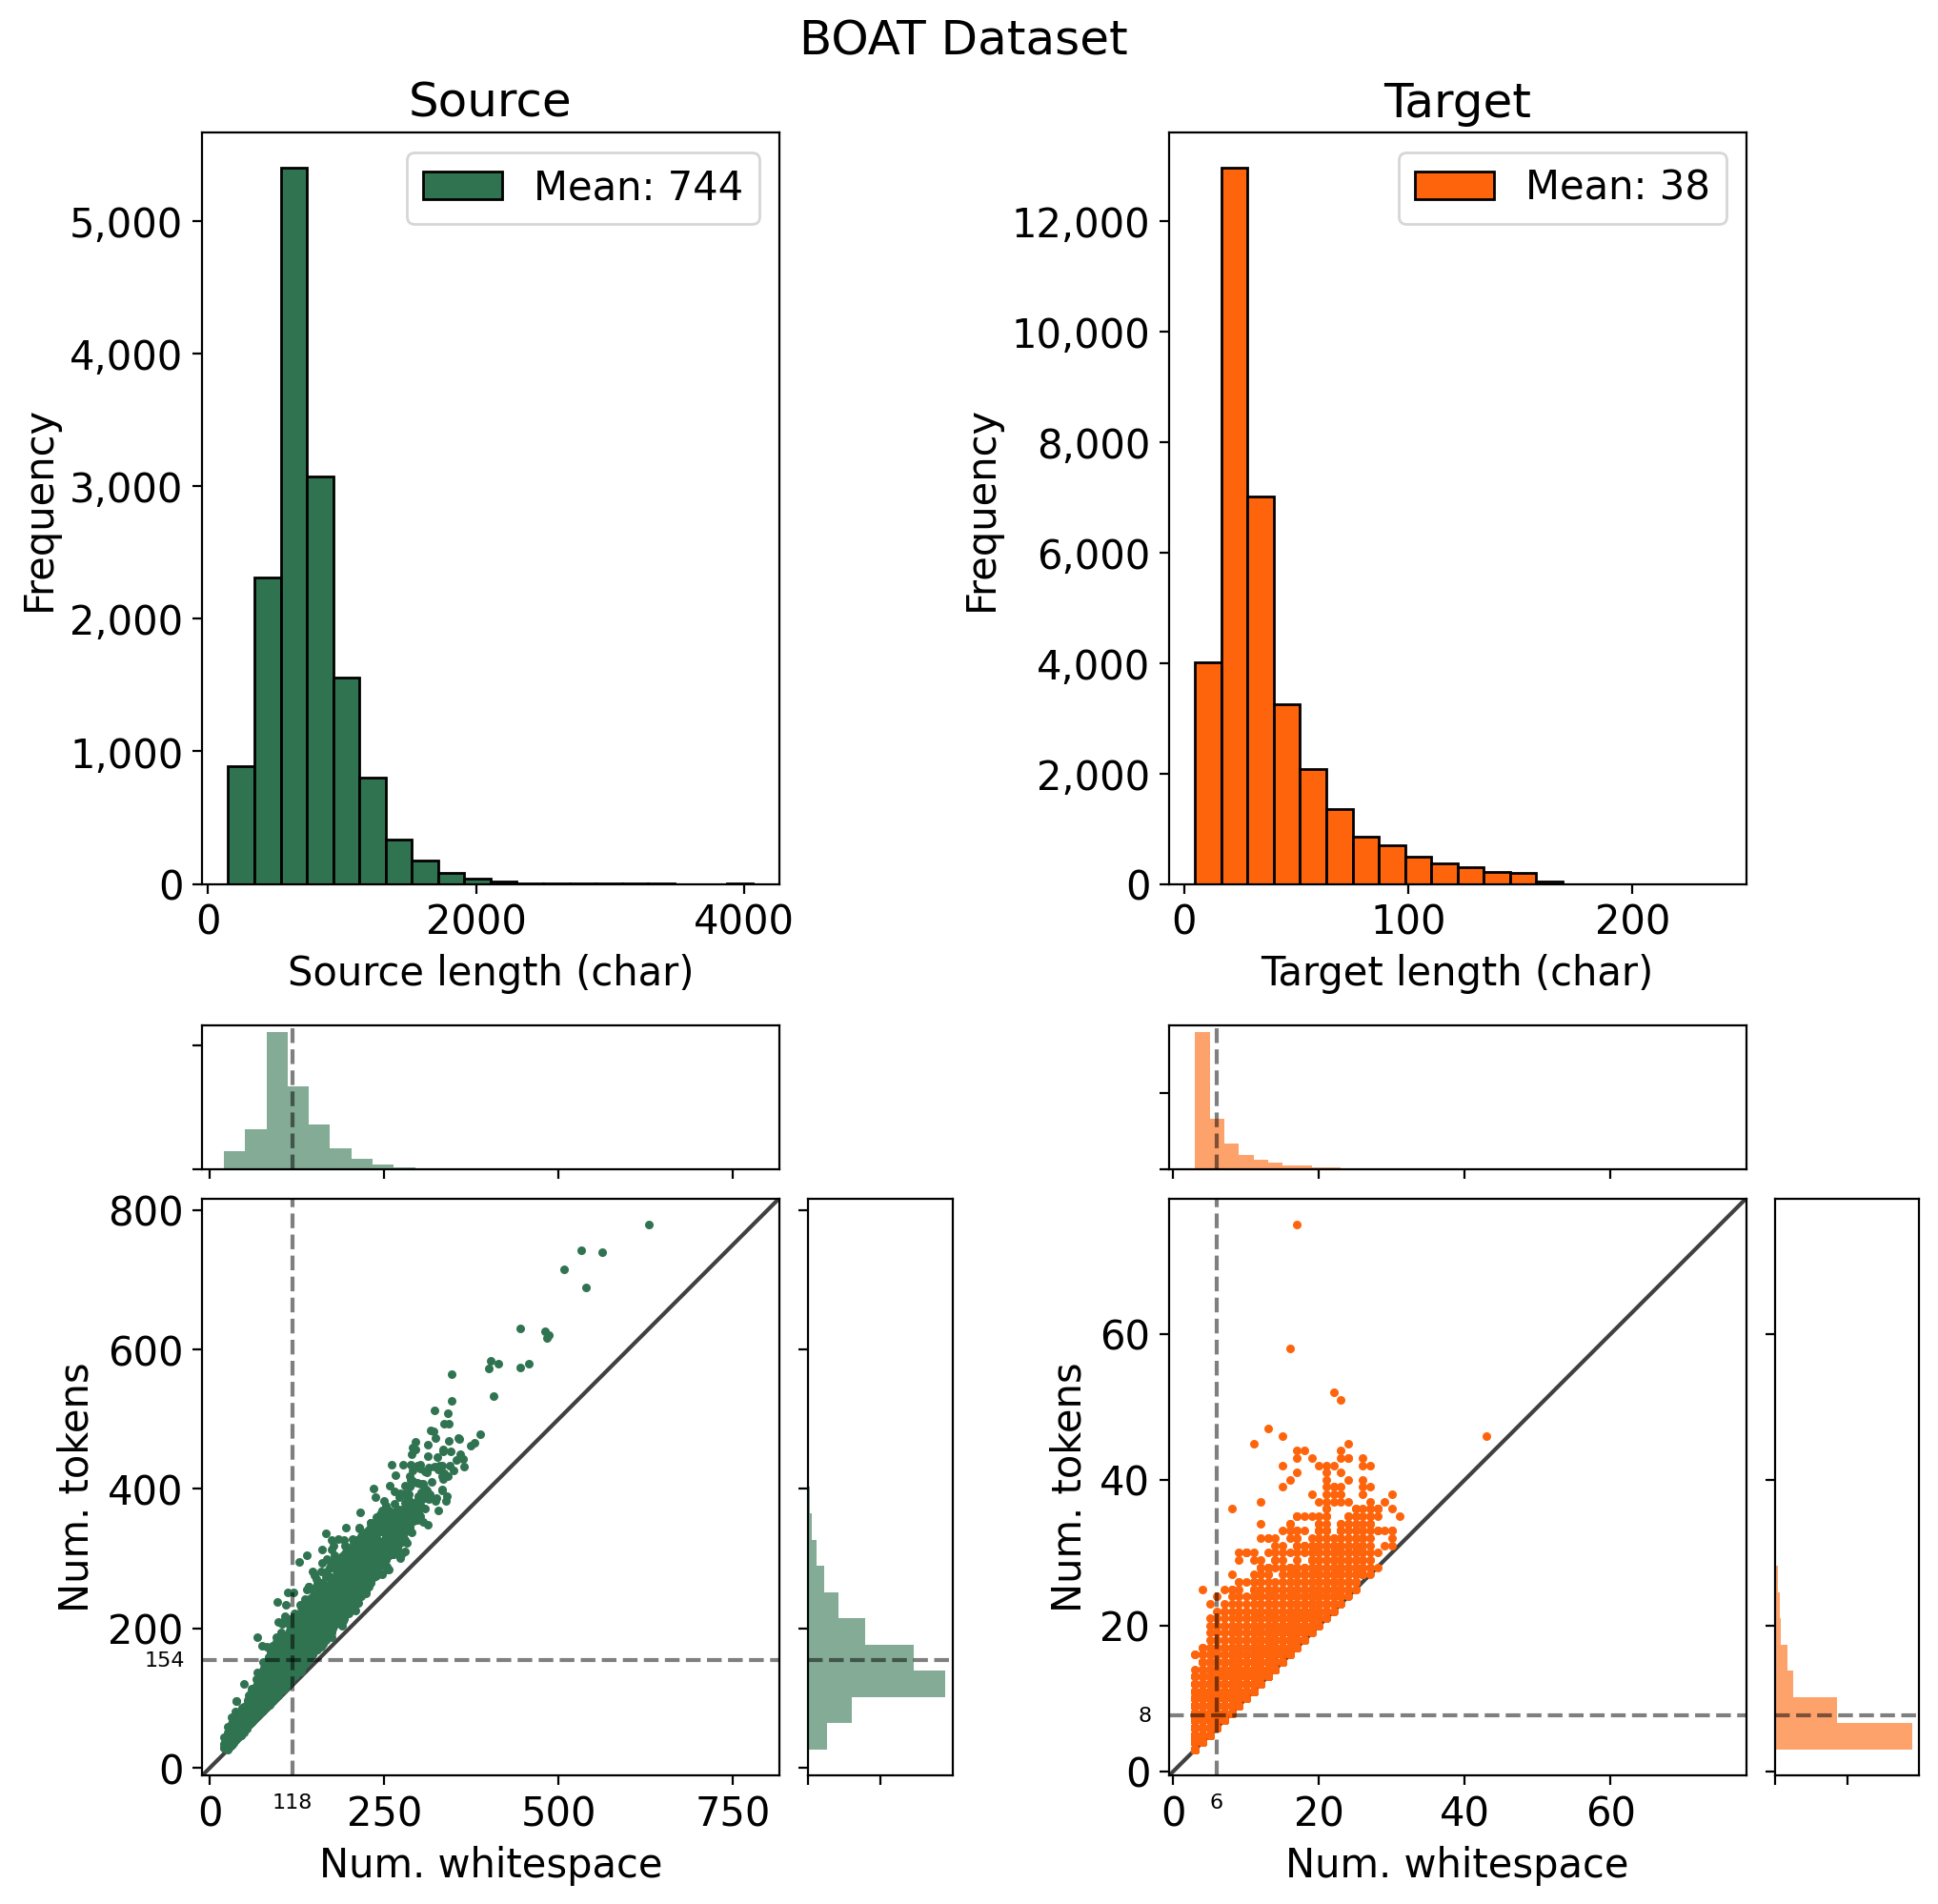

In [81]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def scatter_with_marginals(ax, x, y, color):
    ax.scatter(x, y, s=5, color=color)
    ax.set(
        xlabel="Num. whitespace",
        ylabel="Num. tokens",
    )
    mnx = x.mean()
    mny = y.mean()

    # vertical mean line
    ax.axvline(mnx, linestyle="--", color="k", alpha=0.5)
    ax.text(
        mnx, -0.03,                     # x in data coords, y just below axis
        f"{mnx:.0f}",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top",
        fontsize=8,
    )

    # horizontal mean line
    ax.axhline(mny, linestyle="--", color="k", alpha=0.5)
    ax.text(
        -0.03, mny,                    # x just left of axis, y in data coords
        f"{mny:.0f}",
        transform=ax.get_yaxis_transform(),
        ha="right", va="center",
        fontsize=8,
    )

    # top marginal
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
    ax_histx.hist(x, bins=20, color=color, alpha=0.6)
    plt.setp(ax_histx.get_xticklabels(), visible=False)
    ax_histx.tick_params(axis="y", labelleft=False)
    ax_histx.axvline(mnx, linestyle="--", color="k", alpha=0.5)

    # right marginal
    ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)
    ax_histy.hist(y, bins=20, orientation="horizontal", color=color, alpha=0.6)
    ax_histy.tick_params(axis="x", labelbottom=False)
    ax_histy.axhline(mny, linestyle="--", color="k", alpha=0.5)

    plt.setp(ax_histy.get_yticklabels(), visible=False)
    yex(ax)


# fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2, constrained_layout=True)
# fig.suptitle("BOAT Dataset")

fig = plt.figure(figsize=(10, 10), layout="constrained")
gs = fig.add_gridspec(
    2, 2,
)
axs = gs.subplots()
fig.suptitle("BOAT Dataset")

# ===============================
# TOP ROW — HISTOGRAMS
# ===============================

# --- SOURCE ---
ax = axs[0, 0]

x = pd.Series(wdf.source.unique()).str.len()
mn = x.mean()
ax.hist(x.values, bins=20, edgecolor="k", facecolor="#307351", label=f"Mean: {mn:,.0f}")
ax.set(xlabel="Source length (char)", ylabel="Frequency", title="Source")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax.legend()

# --- TARGET ---
ax = axs[0,1]

x = pd.Series(wdf.target.unique()).str.len()
mn = x.mean()
ax.hist(x.values, bins=20, edgecolor="k", facecolor="#FE640B", label=f"Mean: {mn:,.0f}")
ax.set(xlabel="Target length (char)", ylabel="Frequency", title="Target")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax.legend()

# ===============================
# SECOND ROW — SCATTER + MARGINALS
# ===============================

# --- SOURCE ---
ax = axs[1, 0]

ws = pd.Series(tdf.source.unique()).apply(lambda s: len(s.split()))
toks = pd.Series(tdf.source.unique()).apply(lambda s: len(tokenize(s)[0]))

scatter_with_marginals(ax, ws, toks, "#307351")

# --- TARGET ---
ax = axs[1, 1]

ws = pd.Series(tdf.target.unique()).apply(lambda s: len(s.split()))
toks = pd.Series(tdf.target.unique()).apply(lambda s: len(tokenize(s)[0]))

scatter_with_marginals(ax, ws, toks, "#FE640B")

plt.show()

In [82]:
import pandas as pd

def compute_stats(texts_w, texts_t):
    chars = texts_w.str.len()
    ws = texts_w.apply(lambda s: len(s.split()))
    toks = texts_t.apply(lambda s: len(tokenize(s)[0]))
    return {
        "Char/Sample": chars.mean(),
        "WS/Sample": ws.mean(),
        "Tok/Sample": toks.mean(),
        "N Samples": texts_w.nunique()
    }

source_stats = compute_stats(
    pd.Series(wdf.source.unique()),
    pd.Series(tdf.source.unique())
)

target_stats = compute_stats(
    pd.Series(wdf.target.unique()),
    pd.Series(tdf.target.unique())
)

table = pd.DataFrame([source_stats, target_stats], index=["source", "target"])
table = table.round(0)
table

,Char/Sample,WS/Sample,Tok/Sample,N Samples
source,744.0,118.0,154.0,14701
target,38.0,6.0,8.0,33838


In [83]:
import time

# Apply function with timing
def timed_align(x, fn, ttype):  # fn takes in source and target
    start_time = time.time()
    ctx = x["source"]
    tgt = x["target"]

    if ttype == "whitespace":
        tgt = tgt.strip()

    result = fn(ctx, tgt, ttype)
    end_time = time.time()

    # Calculate elapsed time in milliseconds
    t = (end_time - start_time) * 1000
    return result, t


def align_naive(ctx, tgt, ttype):
    # Return all contiguous occurrences as separate alignments.
    alns = []
    start = 0
    while True:
        idx = ctx.find(tgt, start)
        if idx < 0:
            break

        found = {
            "token": norm_text(tgt),
            "enc_token": -1,
            "start_idx": idx,
            "end_idx": idx + len(tgt),
        }
        alns.append([found])
        start = idx + 1

    return alns


methods = {
    "custom": align_ng,
    "lcs": align_lcs,
    "difflib": align_difflib,
    "naive": align_naive,
}

In [84]:
for m in methods:
    # alignments and time
    tdf[[f"{m}_aln", f"{m}_time_ms"]] = tdf.apply(
        timed_align, axis=1, result_type="expand", args=(methods[m], "token")
    )

    # Full-match alignments (location-free): reconstruct == target.
    tdf[f"{m}_naln"] = tdf.apply(
        lambda r: sum(reconstruct_target_by_idx(r.source, a) == r.target for a in r[f"{m}_aln"]),
        axis=1,
    )

    # Among those full-match alignments, keep their (start,end) pairs.
    tdf[f"{m}_pairs"] = tdf.apply(
        lambda r: set(
            (a[0].get("start_idx", -1), a[-1].get("end_idx", -1))
            for a in r[f"{m}_aln"]
            if reconstruct_target_by_idx(r.source, a) == r.target
        ),
        axis=1,
    )

    tdf[f"{m}_idx_start"] = tdf[f"{m}_pairs"].apply(lambda s: set([p[0] for p in s]))
    tdf[f"{m}_idx_stop"] = tdf[f"{m}_pairs"].apply(lambda s: set([p[1] for p in s]))

    # a match is one where the number of alignments is at least 1
    tdf[f"{m}_match"] = tdf[f"{m}_naln"] > 0


In [85]:
for m in methods:
    # alignments and time
    wdf[[f"{m}_aln", f"{m}_time_ms"]] = wdf.apply(
        timed_align, axis=1, result_type="expand", args=(methods[m], "whitespace")
    )

    # Full-match alignments (location-free): reconstruct == target.
    wdf[f"{m}_naln"] = wdf.apply(
        lambda r: sum(
            reconstruct_target_by_token("", a, " ") == norm_text(r.target.strip())
            for a in r[f"{m}_aln"]
        ),
        axis=1,
    )

    # Among those full-match alignments, keep their (start,end) pairs.
    wdf[f"{m}_pairs"] = wdf.apply(
        lambda r: set(
            (a[0].get("start_idx", -1), a[-1].get("end_idx", -1))
            for a in r[f"{m}_aln"]
            if reconstruct_target_by_token("", a, " ") == norm_text(r.target.strip())
        ),
        axis=1,
    )

    wdf[f"{m}_idx_start"] = wdf[f"{m}_pairs"].apply(lambda s: set([p[0] for p in s]))
    wdf[f"{m}_idx_stop"] = wdf[f"{m}_pairs"].apply(lambda s: set([p[1] for p in s]))

    wdf[f"{m}_match"] = wdf[f"{m}_naln"] > 0


In [86]:
# Contiguous localization: among FULL matches, did we recover at least one gold (start,end) span?
for m in list(methods.keys()):
    tdf[f"{m}_loc"] = tdf.apply(
        lambda r: len(
            set((s, s + len(r.target)) for s in r.idx_start) & r[f"{m}_pairs"]
        ) > 0,
        axis=1,
    )

    wdf[f"{m}_loc"] = wdf.apply(
        lambda r: len(
            set((s, s + len(r.target.strip())) for s in r.idx_start) & r[f"{m}_pairs"]
        ) > 0,
        axis=1,
    )


In [87]:
# full-match accuracy (location-free)
print(tdf["custom_match"].mean()*100)
print(tdf["lcs_match"].mean()*100)
print(tdf["difflib_match"].mean()*100)
print(tdf["naive_match"].mean()*100)

98.49771949828963
98.48346636259977
98.5290763968073
100.0


In [88]:
# full-match accuracy (location-free)
print(wdf["custom_match"].mean()*100)
print(wdf["lcs_match"].mean()*100)
print(wdf["difflib_match"].mean()*100)
print(wdf["naive_match"].mean()*100)

51.45667046750285
51.47662485746864
51.359749144811865
100.0


In [89]:
both = tdf.query("custom_loc & naive_loc").shape[0]
neither = tdf.query("~custom_loc & ~naive_loc").shape[0]
found_only = tdf.query("custom_loc & ~naive_loc").shape[0]
naive_only = tdf.query("~custom_loc & naive_loc").shape[0]

In [90]:
# Create the original DataFrame
tbl = pd.DataFrame(
    [[both, found_only],
     [naive_only, neither]],
    index=["custom_loc True", "custom_loc False"],
    columns=["naive_loc True", "naive_loc False"]
)

# Add row sums
tbl["Total"] = tbl.sum(axis=1)

# Add column sums
tbl.loc["Total"] = tbl.sum(axis=0)
tbl


,naive_loc True,naive_loc False,Total
custom_loc True,34377,0,34377
custom_loc False,703,0,703
Total,35080,0,35080


In [91]:
# Create the original DataFrame
tbl = pd.DataFrame(
    [[both, found_only],
     [naive_only, neither]],
    index=["custom_loc True", "custom_loc False"],
    columns=["naive_loc True", "naive_loc False"]
)

# Add row sums
tbl["Total"] = tbl.sum(axis=1)

# Add column sums
tbl.loc["Total"] = tbl.sum(axis=0)
tbl / tbl.loc["Total", "Total"] * 100

,naive_loc True,naive_loc False,Total
custom_loc True,97.996009,0.0,97.996009
custom_loc False,2.003991,0.0,2.003991
Total,100.000000,0.0,100.000000


In [92]:
times = tdf.assign(ntks_src=tdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
   .groupby("ntks_src")[[
       "custom_time_ms",
       "lcs_time_ms",
       "difflib_time_ms",
       "naive_time_ms",
       ]].mean()
# times = tdf.assign(ntks_src=tdf["source"].apply(lambda x: len(x))) \
#    .groupby("ntks_src")[[
#        "custom_time_ms",
#        "lcs_time_ms",
#        "difflib_time_ms",
#        "naive_time_ms",
#        ]].mean()

In [93]:
def plaw_fit(x, y):
    logx = np.log10(x)
    logy = np.log10(y)
    ceoffs = np.polyfit(logx, logy, 1)
    b, loga = ceoffs
    a = 10**loga

    x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 1000)
    y_fit = a * x_fit**b
    return (x_fit, y_fit, a, b)

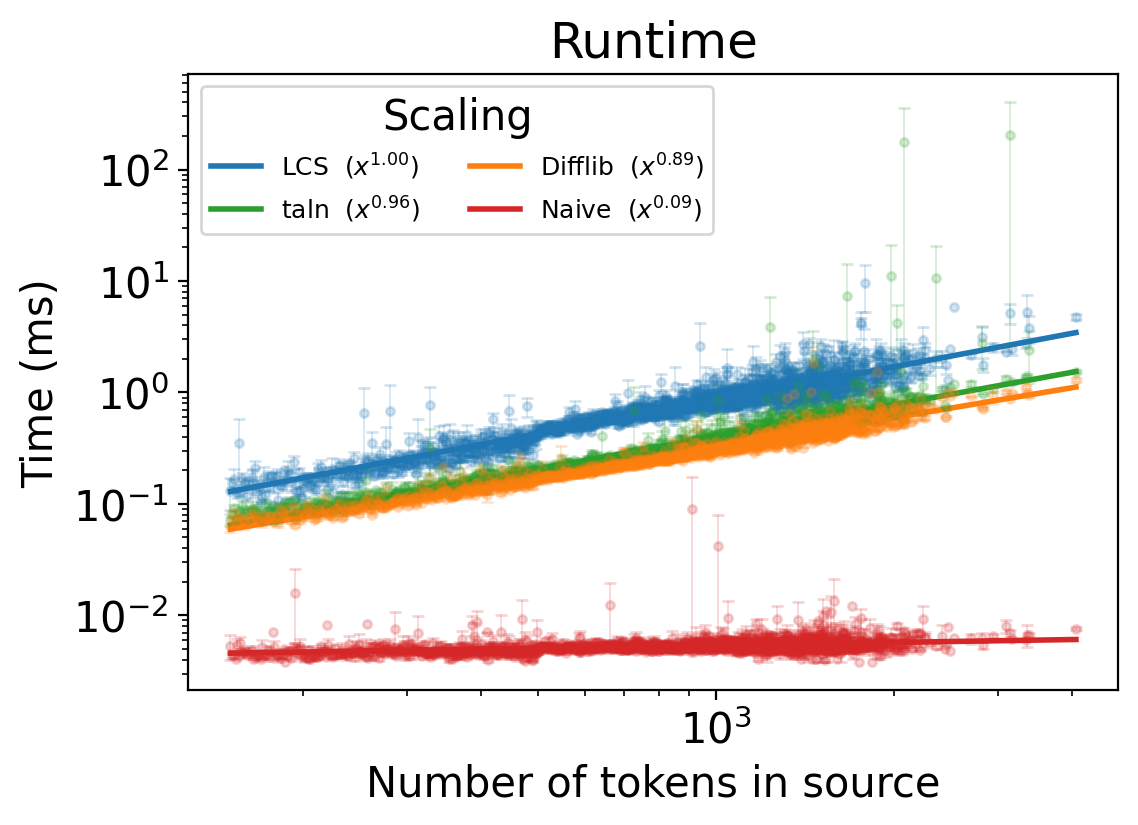

In [94]:
import numpy as np
import matplotlib.pyplot as plt

METHOD_COLS = [
    "lcs_time_ms",
    "custom_time_ms",   # taln
    "difflib_time_ms",
    "naive_time_ms",
]

LABELS = {
    "lcs_time_ms":     "LCS",
    "custom_time_ms":  "taln",
    "difflib_time_ms": "Difflib",
    "naive_time_ms":   "Naive",
}

# COLORS = {
#     "lcs_time_ms":     "#1f77b4",  # blue
#     "custom_time_ms":  "#ff7f0e",  # orange
#     "difflib_time_ms": "#2ca02c",  # green
#     "naive_time_ms":   "#d62728",  # red
# }


COLORS = {
    "lcs_time_ms":     "#1f77b4",  # blue
    "custom_time_ms":  "#2ca02c",  # green
    "difflib_time_ms": "#ff7f0e",  # orange
    "naive_time_ms":   "#d62728",  # red
}

def plaw_fit(x, y):
    logx = np.log10(x)
    logy = np.log10(y)
    b, loga = np.polyfit(logx, logy, 1)
    a = 10**loga
    x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
    y_fit = a * x_fit**b
    return x_fit, y_fit, a, b

# ---- aggregate timings: mean + sem per source length ------------------------
g = (
    tdf.assign(ntks_src=tdf["source"].apply(len))
       .groupby("ntks_src")[METHOD_COLS]
)

means = g.mean()
sems  = g.sem()

x = means.index.values

# ---- plot -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

for k in METHOD_COLS:
    y_mean = means[k].values
    y_sem  = sems[k].values

    # fit on means
    x_fit, y_fit, a, b = plaw_fit(x, y_mean)

    # line for fitted power law
    ax.plot(
        x_fit, y_fit,
        color=COLORS[k],
        lw=2,
    )

    # points + vertical uncertainty
    ax.errorbar(
        x, y_mean,
        yerr=y_sem,
        fmt="o",
        markersize=3,
        lw=0.6,
        capsize=2,
        color=COLORS[k],
        ecolor=COLORS[k],
        alpha=0.2,
    )

    # concise legend label – focus on scaling
    ax.plot([], [], color=COLORS[k], lw=2,
            label=fr"{LABELS[k]}  ($x^{{{b:.2f}}}$)")

ax.set(
    xlabel="Number of tokens in source",
    ylabel="Time (ms)",
    xscale="log",
    yscale="log",
    title="Runtime"
)

# legend below, horizontal, out of the way
leg = ax.legend(
    loc="upper left",
    # bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=True,
    fontsize=9,
    title="Scaling"
)

plt.show()

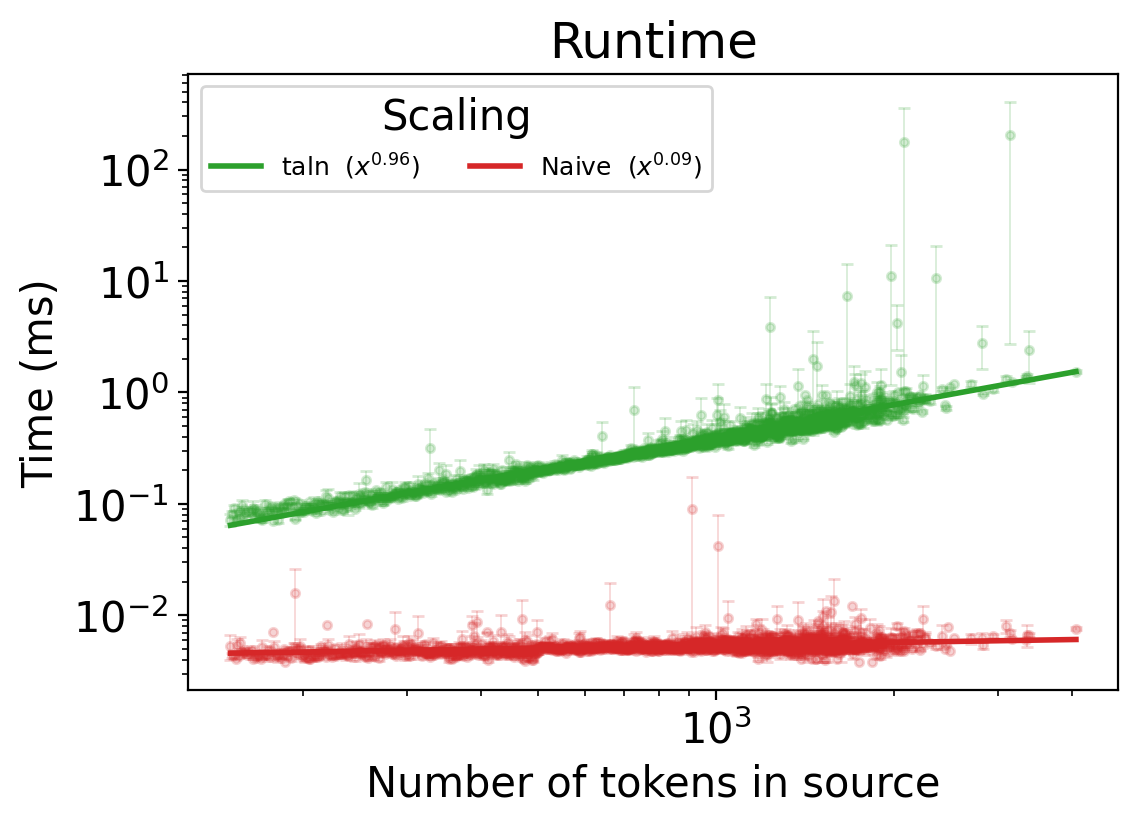

In [95]:
import numpy as np
import matplotlib.pyplot as plt

METHOD_COLS = [
    # "lcs_time_ms",
    "custom_time_ms",   # taln
    # "difflib_time_ms",
    "naive_time_ms",
]

LABELS = {
    "lcs_time_ms":     "LCS",
    "custom_time_ms":  "taln",
    "difflib_time_ms": "Difflib",
    "naive_time_ms":   "Naive",
}

# COLORS = {
#     "lcs_time_ms":     "#1f77b4",  # blue
#     "custom_time_ms":  "#ff7f0e",  # orange
#     "difflib_time_ms": "#2ca02c",  # green
#     "naive_time_ms":   "#d62728",  # red
# }


COLORS = {
    "lcs_time_ms":     "#1f77b4",  # blue
    "custom_time_ms":  "#2ca02c",  # green
    "difflib_time_ms": "#ff7f0e",  # orange
    "naive_time_ms":   "#d62728",  # red
}

def plaw_fit(x, y):
    logx = np.log10(x)
    logy = np.log10(y)
    b, loga = np.polyfit(logx, logy, 1)
    a = 10**loga
    x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
    y_fit = a * x_fit**b
    return x_fit, y_fit, a, b

# ---- aggregate timings: mean + sem per source length ------------------------
g = (
    tdf.assign(ntks_src=tdf["source"].apply(len))
       .groupby("ntks_src")[METHOD_COLS]
)

means = g.mean()
sems  = g.sem()

x = means.index.values

# ---- plot -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

for k in METHOD_COLS:
    y_mean = means[k].values
    y_sem  = sems[k].values

    # fit on means
    x_fit, y_fit, a, b = plaw_fit(x, y_mean)

    # line for fitted power law
    ax.plot(
        x_fit, y_fit,
        color=COLORS[k],
        lw=2,
    )

    # points + vertical uncertainty
    ax.errorbar(
        x, y_mean,
        yerr=y_sem,
        fmt="o",
        markersize=3,
        lw=0.6,
        capsize=2,
        color=COLORS[k],
        ecolor=COLORS[k],
        alpha=0.2,
    )

    # concise legend label – focus on scaling
    ax.plot([], [], color=COLORS[k], lw=2,
            label=fr"{LABELS[k]}  ($x^{{{b:.2f}}}$)")

ax.set(
    xlabel="Number of tokens in source",
    ylabel="Time (ms)",
    xscale="log",
    yscale="log",
    title="Runtime"
)

# legend below, horizontal, out of the way
leg = ax.legend(
    loc="upper left",
    # bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=True,
    fontsize=9,
    title="Scaling"
)

plt.show()

In [96]:
tacc = tdf.assign(ntks_ctx=tdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

wacc = wdf.assign(ntks_ctx=wdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

In [97]:
wdf[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]].agg(lambda x: x.sum() / x.count() * 100)
wdf[["custom_match", "lcs_match", "difflib_match", "naive_match"]].agg(lambda x: x.sum() / x.count() * 100)


custom_match      51.456670
lcs_match         51.476625
difflib_match     51.359749
naive_match      100.000000
dtype: float64

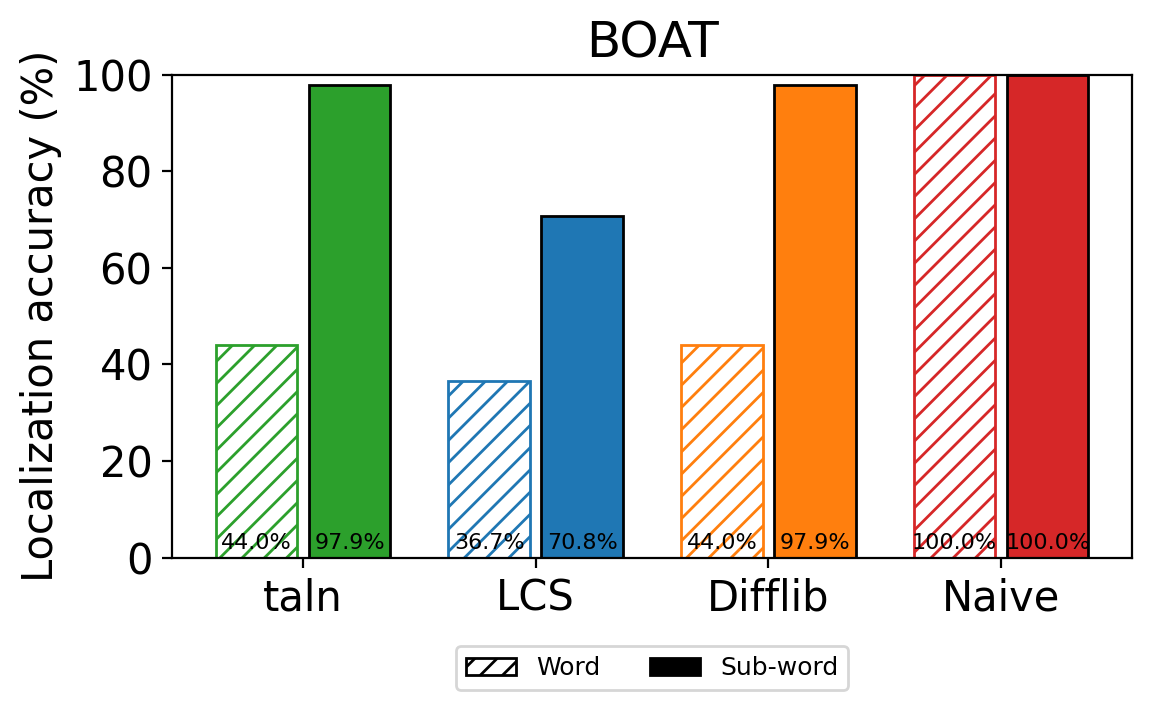

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

fig, ax = plt.subplots(figsize=(6, 4))

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}
x = np.arange(len(methods.keys()))

width = 0.35
gap = 0.025

# --- sub-word (tacc) ---------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = tacc[f"{m}_loc"]
    y_mean = np.mean(y)
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],   # solid color
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- word (wacc) -------------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = wacc[f"{m}_loc"]
    y_mean = np.mean(y)
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",           # stripes
        linewidth=1,
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)


# --- axes / labels -----------------------------------------------------------
ax.set(
    ylabel="Localization accuracy (%)",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, 100),
    title="BOAT",
)

# legend
legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]


ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [114]:
tacc = tdf.assign(ntks_ctx=tdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_match", "lcs_match", "difflib_match", "naive_match"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

wacc = wdf.assign(ntks_ctx=wdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_match", "lcs_match", "difflib_match", "naive_match"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

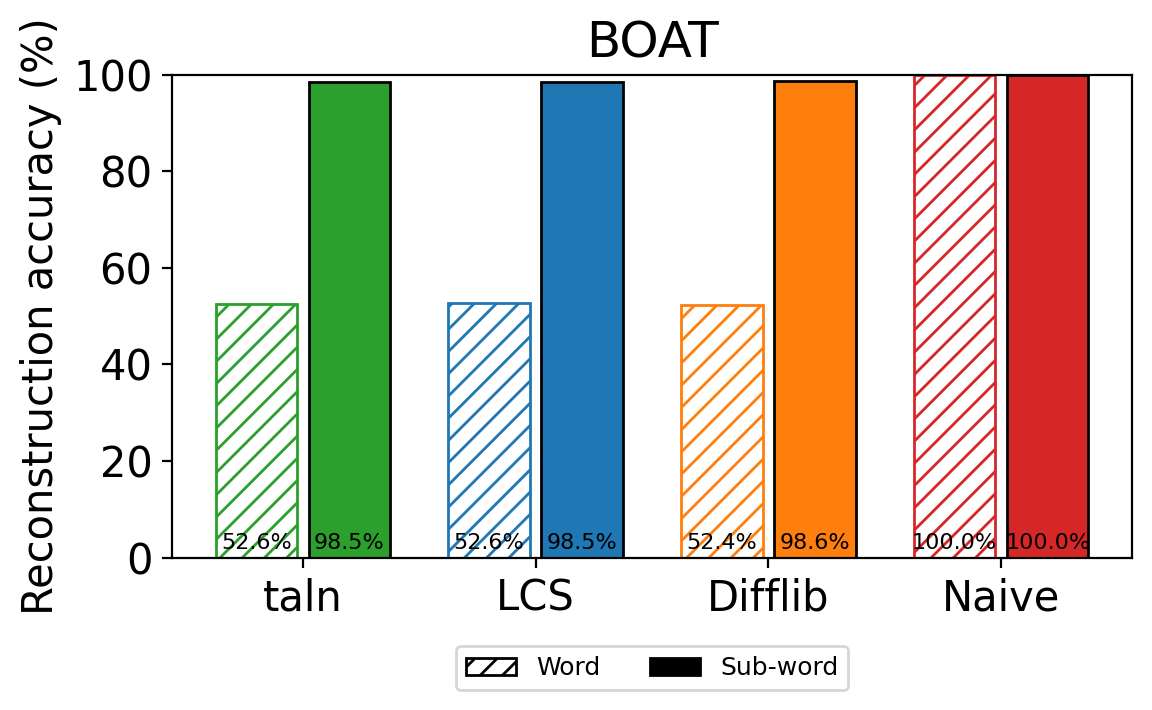

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

fig, ax = plt.subplots(figsize=(6, 4))

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}
x = np.arange(len(methods.keys()))

width = 0.35
gap = 0.025

# --- sub-word (tacc) ---------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = tacc[f"{m}_match"]
    y_mean = np.mean(y)
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],   # solid color
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- word (wacc) -------------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = wacc[f"{m}_match"]
    y_mean = np.mean(y)
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",           # stripes
        linewidth=1,
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)


# --- axes / labels -----------------------------------------------------------
ax.set(
    ylabel="Reconstruction accuracy (%)",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, 100),
    title="BOAT",
)

# legend
legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]


ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()

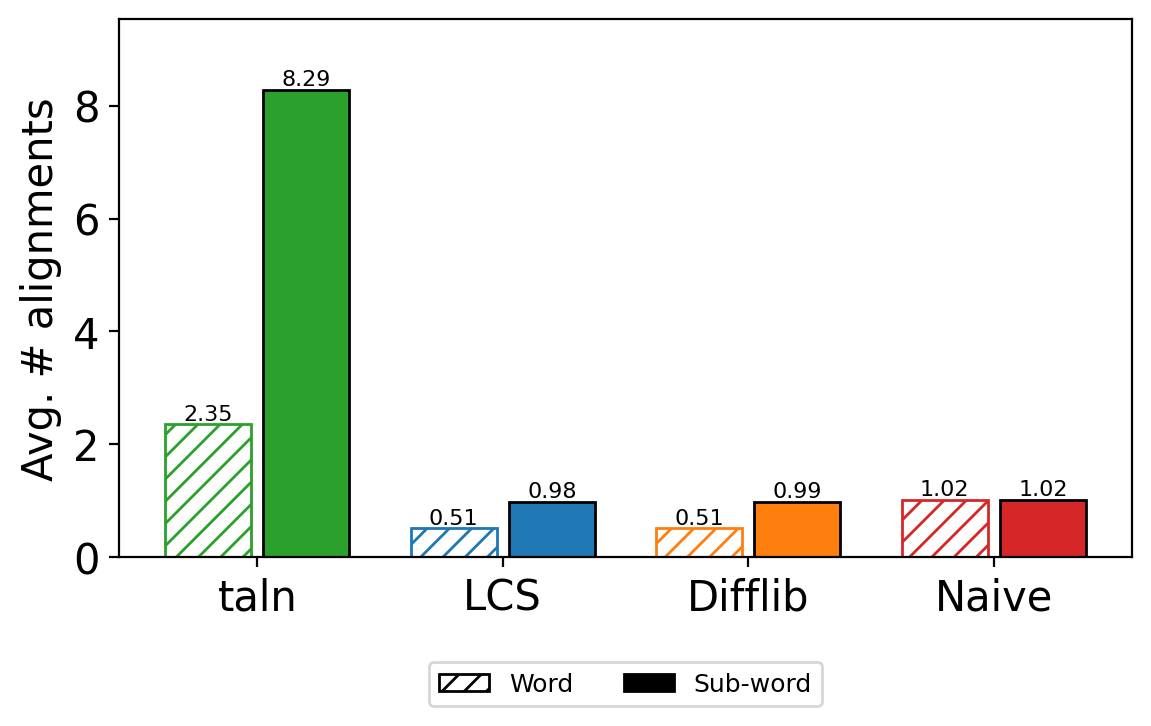

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Average number of FULL-MATCH alignments returned per (source,target) for each method.
# Sub-word = tdf (token) and Word = wdf (whitespace).

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# --- sub-word (tdf) ----------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax.text(center, y_mean, f"{y_mean:.2f}", ha="center", va="bottom", fontsize=8)

# --- word (wdf) --------------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax.text(center, y_mean, f"{y_mean:.2f}", ha="center", va="bottom", fontsize=8)

ax.set(
    ylabel="Avg. # alignments",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, max(tdf[[f"{m}_naln" for m in methods.values()]].mean().max(), wdf[[f"{m}_naln" for m in methods.values()]].mean().max()) * 1.15),
)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()


In [102]:
# Variance of #FULL-MATCH alignments per (source,target) across the dataset
rows = []
for label, m in methods.items():
    rows.append({
        "method": label,
        "subword_mean": float(tdf[f"{m}_naln"].mean()),
        "subword_var": float(tdf[f"{m}_naln"].var()),
        "word_mean": float(wdf[f"{m}_naln"].mean()),
        "word_var": float(wdf[f"{m}_naln"].var()),
    })

var_tbl = pd.DataFrame(rows).set_index("method").round(3)
var_tbl


,subword_mean,subword_var,word_mean,word_var
method,,,,
taln,8.287,26613.582,2.352,716.764
LCS,0.985,0.015,0.515,0.250
Difflib,0.985,0.014,0.514,0.250
Naive,1.018,0.023,1.018,0.024


In [103]:
tacc.mean(), wacc.mean()

(custom_match      98.536637
 lcs_match         98.547477
 difflib_match     98.587291
 naive_match      100.000000
 dtype: float64,
 custom_match      52.577361
 lcs_match         52.617625
 difflib_match     52.387611
 naive_match      100.000000
 dtype: float64)

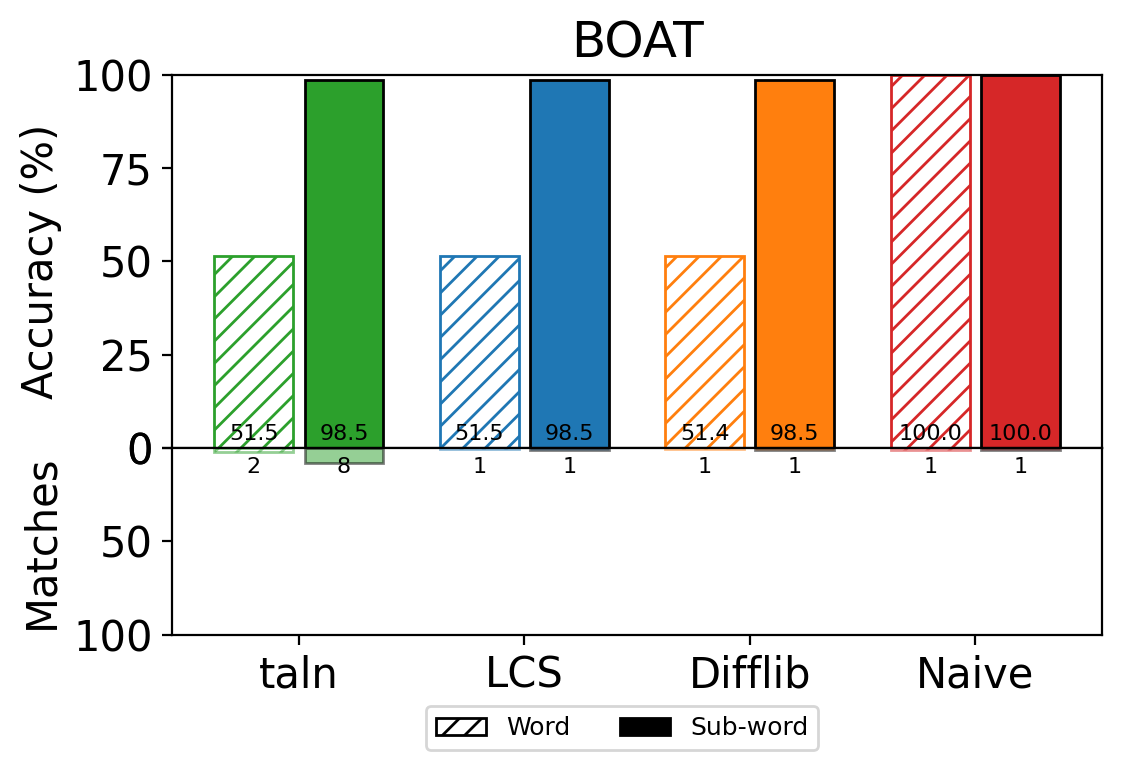

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(6, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# make the panels touch
fig.subplots_adjust(hspace=0)

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# ===============================
# Top: reconstruction accuracy
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_match"].mean() * 100)
    center = idx + (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_match"].mean() * 100)
    center = idx - (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

ax_top.set(
    ylabel="Accuracy (%)",
    ylim=(0, 100),
    title="BOAT"
)

# hide top x tick labels (shared x-axis)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# ===============================
# Bottom: avg # alignments (flipped)
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.0f}", ha="center", va="top", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.0f}", ha="center", va="top", fontsize=8)

ax_bot.set(
    ylabel="Matches",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0,100)
)

# flip y-axis so it reads like the barplot is glued upside-down
ax_bot.invert_yaxis()

# remove the touching spines so the join reads as a single panel
# ax_top.spines["bottom"].set_visible(False)

# ax_bot.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

# legend below the bottom x tick labels
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=9,
)

# NOTE: avoid tight_layout() here; it tends to re-introduce hspace.
fig.subplots_adjust(hspace=0, bottom=0.18)

plt.show()


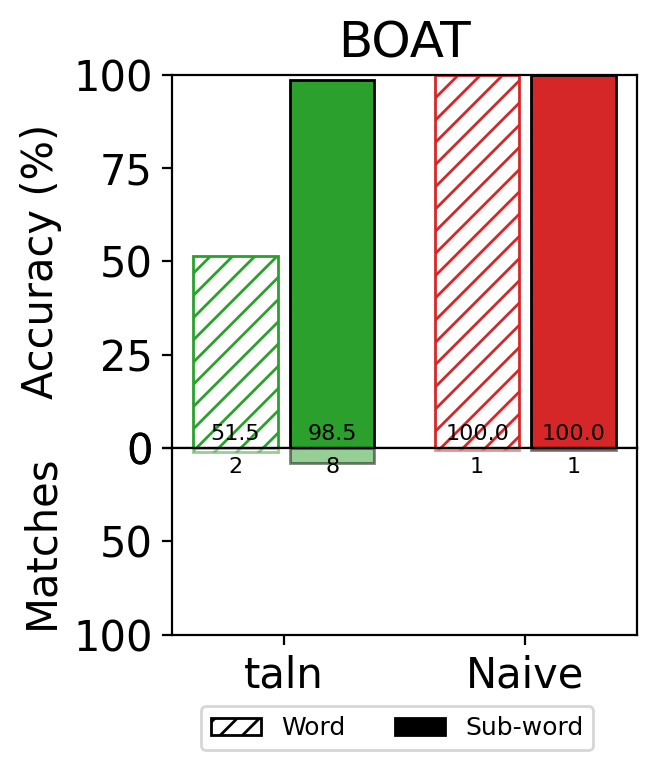

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
    "naive":   "#d62728",  # red
}

methods = {
    "taln": "custom", 
    # "LCS": "lcs", 
    # "Difflib": "difflib", 
    "Naive": "naive"}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(3, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# make the panels touch
fig.subplots_adjust(hspace=0)

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# ===============================
# Top: reconstruction accuracy
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_match"].mean() * 100)
    center = idx + (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_match"].mean() * 100)
    center = idx - (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

ax_top.set(
    ylabel="Accuracy (%)",
    ylim=(0, 100),
    title="BOAT"
)

# hide top x tick labels (shared x-axis)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# ===============================
# Bottom: avg # alignments (flipped)
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.0f}", ha="center", va="top", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.0f}", ha="center", va="top", fontsize=8)

ax_bot.set(
    ylabel="Matches",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0,100)
)

# flip y-axis so it reads like the barplot is glued upside-down
ax_bot.invert_yaxis()

# remove the touching spines so the join reads as a single panel
# ax_top.spines["bottom"].set_visible(False)

# ax_bot.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

# legend below the bottom x tick labels
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=9,
)

# NOTE: avoid tight_layout() here; it tends to re-introduce hspace.
fig.subplots_adjust(hspace=0, bottom=0.18)

plt.show()


In [106]:
tdf.source.str.split(" ").apply(lambda x: [len(i) for i in x]).explode().mean()

np.float64(5.328801676533154)

In [107]:
tdf.columns

Index(['source', 'target', 'idx_start', 'custom_aln', 'custom_time_ms',
       'custom_naln', 'custom_pairs', 'custom_idx_start', 'custom_idx_stop',
       'custom_match', 'lcs_aln', 'lcs_time_ms', 'lcs_naln', 'lcs_pairs',
       'lcs_idx_start', 'lcs_idx_stop', 'lcs_match', 'difflib_aln',
       'difflib_time_ms', 'difflib_naln', 'difflib_pairs', 'difflib_idx_start',
       'difflib_idx_stop', 'difflib_match', 'naive_aln', 'naive_time_ms',
       'naive_naln', 'naive_pairs', 'naive_idx_start', 'naive_idx_stop',
       'naive_match', 'custom_loc', 'lcs_loc', 'difflib_loc', 'naive_loc'],
      dtype='object')

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute per-row token + char counts ------------------------------------
df = tdf.assign(
    n_chars = tdf["source"].apply(len),
    n_tokens = tdf["source"].apply(lambda x: len(tokenize(x)[0])),
)

# --- Compute accuracy per token-length bucket --------------------------------
tacc = (
    tdf.assign(ntks_ctx=tdf["source"].apply(lambda x: len(tokenize(x)[0])))
       .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]]
       .agg(lambda x: x.sum() / x.count() * 100)
)

# --- Attach accuracy back to each row ---------------------------------------
# choose which method’s accuracy to plot (change name here)
method = "custom_loc"

df = df.assign(
    accuracy = df["n_tokens"].map(tacc[method])
)


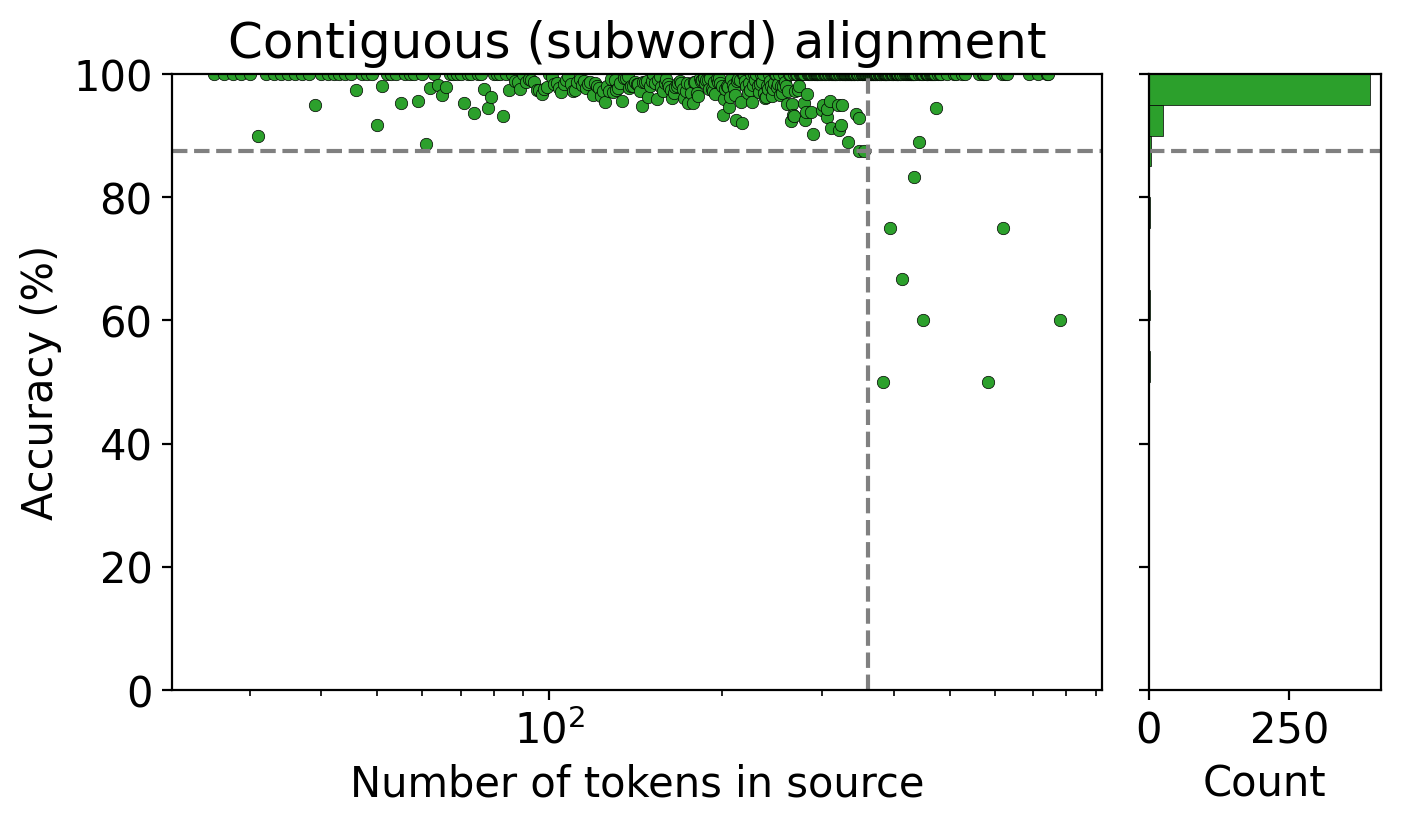

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# --- pick which accuracy to use ---------------------------------------------
method = "custom_loc"  # or "lcs_loc", "difflib_loc", "naive_loc"

acc_by_tokens = (
    tacc[method]
    .reset_index()
    .rename(columns={"ntks_ctx": "n_tokens", method: "accuracy"})
    .sort_values("n_tokens")
)

# --- plot: tokens vs accuracy -----------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    acc_by_tokens["n_tokens"],
    acc_by_tokens["accuracy"],
    s=20,
    edgecolor="k",
    linewidths=0.25,
    facecolor="#2ca02c",
)

cu_ntks = 360
ax.axvline(cu_ntks, color="grey", linestyle="--")
min_acc = acc_by_tokens.loc[acc_by_tokens["n_tokens"] <= cu_ntks, "accuracy"].min()
ax.axhline(min_acc, color="grey", linestyle="--")

ax.set(
    xlabel="Number of tokens in source",
    ylabel="Accuracy (%)",
    xscale="log",
    ylim=(0, 100),
    title="Contiguous (subword) alignment",
)

# --- right marginal: accuracy distribution -----------------------------------
ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)

bins = np.arange(0, 101, 5)
ax_histy.hist(
    acc_by_tokens["accuracy"],
    bins=bins,
    orientation="horizontal",
    color="#2ca02c",
    edgecolor="k",
    linewidth=0.25,
)

# same hline on marginal
ax_histy.axhline(min_acc, color="grey", linestyle="--")

ax_histy.tick_params(axis="x", labelbottom=True)
plt.setp(ax_histy.get_yticklabels(), visible=False)

ax_histy.set_xlabel("Count")

plt.show()

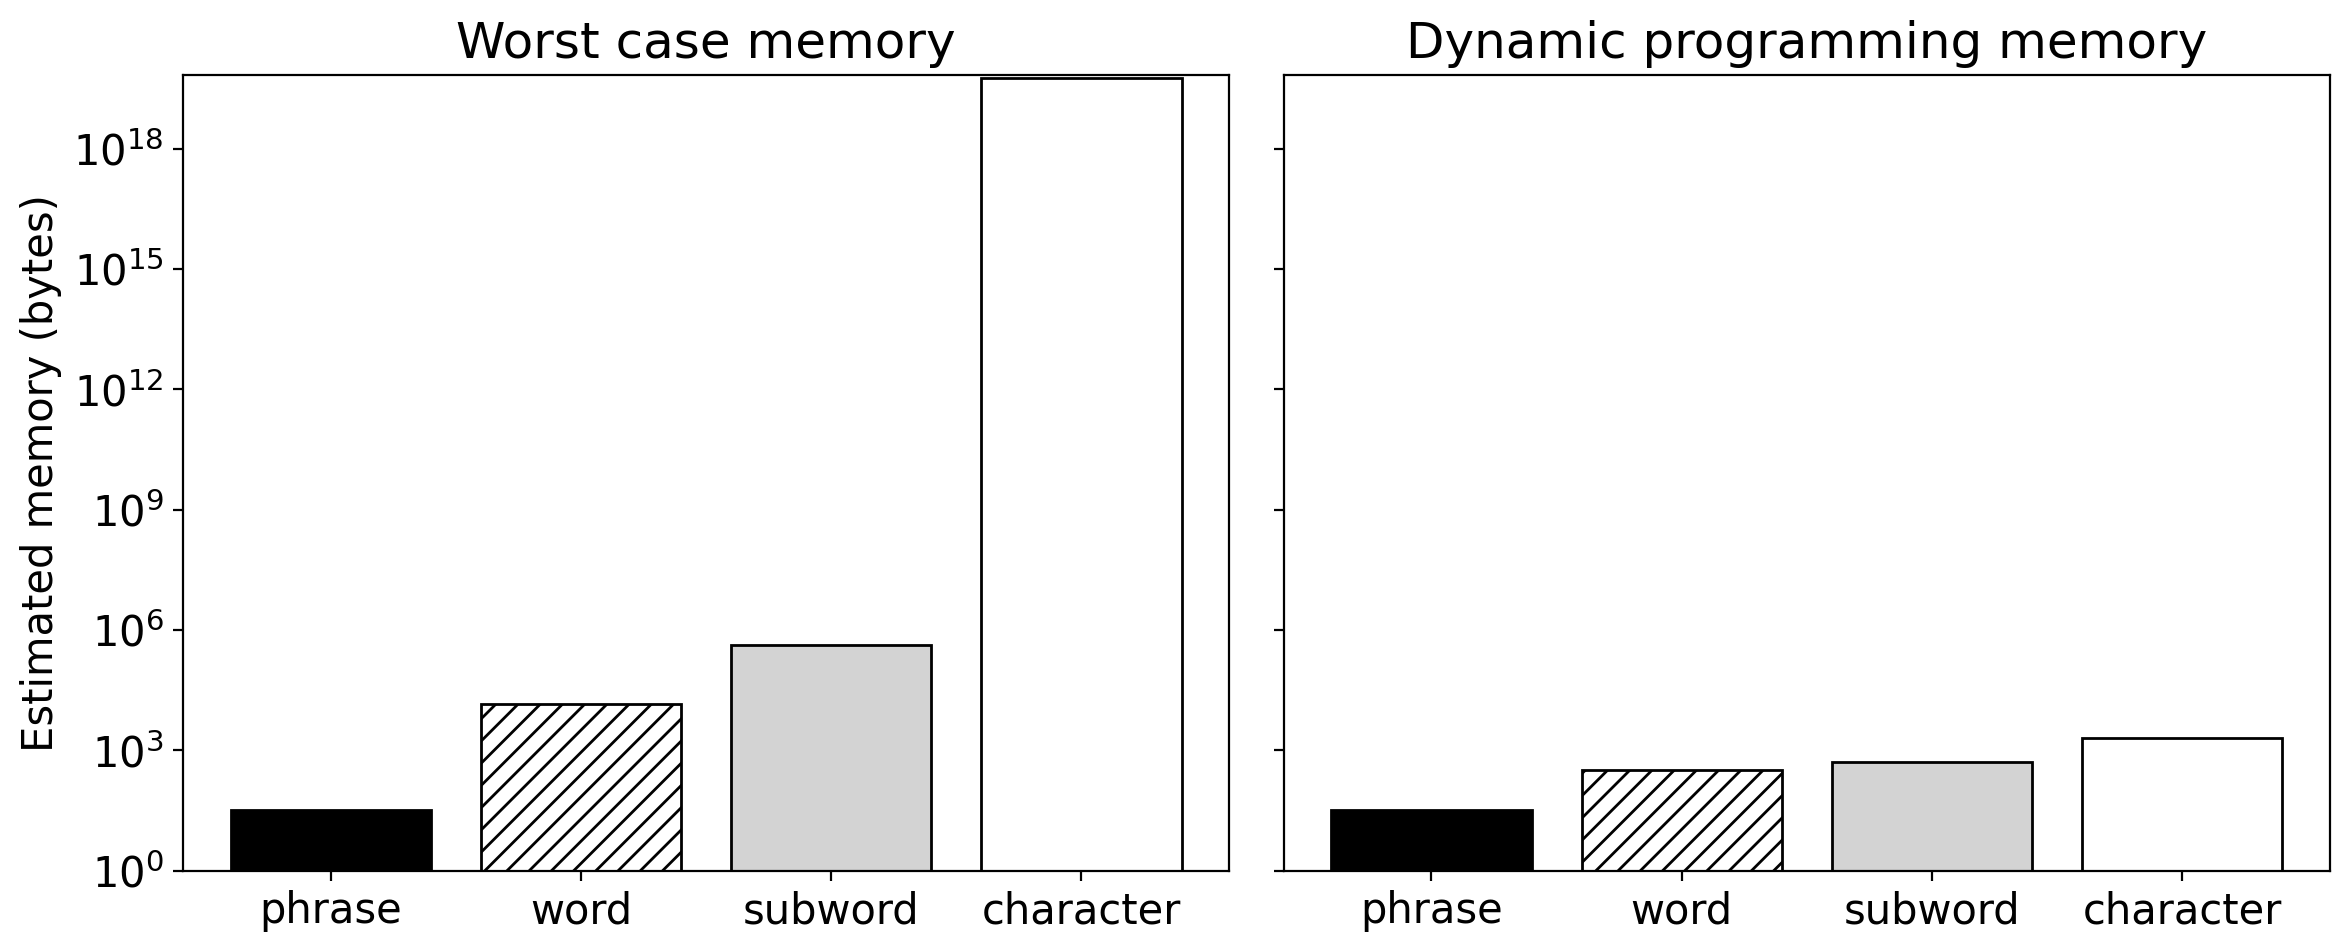

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Simplified memory-complexity illustration for fixed context length L (chars) and fixed span m (chars).
# - phrase: contiguous placements = (L - m + 1)
# - worst case (tokens/words/chars): ~ C(n, m)
# - dynamic programming (tokens/words/chars): ~ n*m

L = 64
m_chars = 32


avg_chars_per_unit = {
    "word": 6.0,
    "subword": 4.0,
    "character": 1.0,
}

order = ["phrase", "word", "subword", "character"]

bytes_per_unit = {
    # rough byte cost per unit (token string length proxy)
    "phrase": 1.0,  # phrase stored as raw characters
    "word": float(avg_chars_per_unit["word"]),
    "subword": float(avg_chars_per_unit["subword"]),
    "character": 1.0,
}

worst = []
dp = []

for g in order:
    if g == "phrase":
        # contiguous phrase search can stream matches; peak memory is O(m)
        mem_phrase = m_chars * bytes_per_unit[g]
        worst.append(mem_phrase)
        dp.append(mem_phrase)
        continue

    n = max(1, int(round(L / avg_chars_per_unit[g])))
    m = max(1, int(round(m_chars / avg_chars_per_unit[g])))
    m = min(m, n)

    # Worst-case enumeration ~ C(n,m) alignments, each stores ~ m units
    logC = (math.lgamma(n + 1) - math.lgamma(m + 1) - math.lgamma(n - m + 1))
    worst.append(math.exp(logC) * m * bytes_per_unit[g])

    # DP baseline ~ n*m table
    dp.append((n * m) * bytes_per_unit[g])

x = np.arange(len(order))

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ymax = max(max(worst), max(dp))
ymax = max(ymax, 1)
yhi = ymax * 1.2

# --- worst case --------------------------------------------------------------
ax = axs[0]
bar_worst = ax.bar(x, worst, color="lightgrey", edgecolor="black", linewidth=1)

for patch, g in zip(bar_worst.patches, order):
    if g == "phrase":
        patch.set_facecolor("black")
        patch.set_edgecolor("black")
    elif g == "word":
        patch.set_facecolor("white")
        patch.set_edgecolor("black")
        patch.set_hatch("///")
    elif g == "character":
        patch.set_facecolor("white")
        patch.set_edgecolor("black")

ax.set(**{
    "title": "Worst case memory",
    "ylabel": "Estimated memory (bytes)",
    "xticks": x,
    "xticklabels": order,
})
ax.set_yscale("log")
ax.set_ylim(1, yhi)

# --- dynamic programming -----------------------------------------------------
ax = axs[1]
bar_dp = ax.bar(x, dp, color="lightgrey", edgecolor="black", linewidth=1)

for patch, g in zip(bar_dp.patches, order):
    if g == "phrase":
        patch.set_facecolor("black")
        patch.set_edgecolor("black")
    elif g == "word":
        patch.set_facecolor("white")
        patch.set_edgecolor("black")
        patch.set_hatch("///")
    elif g == "character":
        patch.set_facecolor("white")
        patch.set_edgecolor("black")

ax.set(**{
    "title": "Dynamic programming memory",
    "xticks": x,
    "xticklabels": order,
})
ax.set_yscale("log")
ax.set_ylim(1, yhi)
ax.tick_params(axis="y", labelleft=False)
ax.set_ylabel("")

# fig.suptitle(
#     f"Estimated bytes (proxy): bytes/unit≈chars/unit; L={L} chars; m={m_chars} chars"
# )
plt.tight_layout()
plt.show()


In [111]:
# --- Diagnostic: why whitespace reconstruction can be low ----------------------
# A whitespace-token method can only fully reconstruct targets that align to
# whitespace token boundaries (start/end at whole-word boundaries).

wdf_dbg = wdf.reset_index(drop=False).copy()

wdf_dbg["t_raw"] = wdf_dbg["target"].astype(str).str.strip()
wdf_dbg["t_norm"] = wdf_dbg["t_raw"].apply(norm_text)
wdf_dbg["s_norm"] = wdf_dbg["source"].astype(str).apply(norm_text)

wdf_dbg["ws_tokens"] = wdf_dbg["s_norm"].apply(lambda s: tokenize(s, "whitespace")[0])
wdf_dbg["ws_starts"] = wdf_dbg["ws_tokens"].apply(lambda toks: {t["start_idx"] for t in toks})
wdf_dbg["ws_ends"] = wdf_dbg["ws_tokens"].apply(lambda toks: {t["end_idx"] for t in toks})


def ws_boundary_aligned(row) -> bool:
    s = row["s_norm"]
    t = row["t_norm"]
    starts = row["ws_starts"]
    ends = row["ws_ends"]

    start = 0
    while True:
        i = s.find(t, start)
        if i < 0:
            return False
        j = i + len(t)
        if (i in starts) and (j in ends):
            return True
        start = i + 1


wdf_dbg["ws_boundary_aligned"] = wdf_dbg.apply(ws_boundary_aligned, axis=1)

pct = float(wdf_dbg["ws_boundary_aligned"].mean() * 100)
print(f"wdf whitespace-boundary-alignable targets (normalized): {pct:.2f}%")

# show a few concrete counterexamples
bad = wdf_dbg[~wdf_dbg["ws_boundary_aligned"]].head(8)
for _, r in bad.iterrows():
    s = r["s_norm"]
    t = r["t_norm"]
    i = s.find(t)
    j = i + len(t) if i >= 0 else -1

    left = max(0, (i if i >= 0 else 0) - 40)
    right = min(len(s), (j if j >= 0 else 0) + 40)

    print("\n---")
    print("target:", repr(r["t_raw"]))
    print("norm  :", repr(t))
    print("first occurrence in norm(source):", (i, j))
    print("source snippet:", repr(s[left:right]))


wdf whitespace-boundary-alignable targets (normalized): 44.92%

---
target: 'a locus (or region) of DNA that encodes a functional RNA or protein product'
norm  : 'a locus (or region) of DNA that encodes a functional RNA or protein product'
first occurrence in norm(source): (11, 86)
source snippet: ' A gene is a locus (or region) of DNA that encodes a functional RNA or protein product, and is the molecular unit of heredity.'

---
target: 'blood type, risk for specific diseases, or the thousands of basic biochemical processes that comprise life'
norm  : 'blood type, risk for specific diseases, or the thousands of basic biochemical processes that comprise life'
first occurrence in norm(source): (480, 586)
source snippet: 'ber of limbs, and some are not, such as blood type, risk for specific diseases, or the thousands of basic biochemical processes that comprise life.'

---
target: 'eye colour or number of limbs'
norm  : 'eye colour or number of limbs'
first occurrence in norm(source): (42